In [ ]:
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'agriculture-crop-images:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F775339%2F1353477%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240420%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240420T075753Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D3b259c990681dc935fef15050d533f8f9444dd32b777e86ccfd3463b0f5f03762af47e10ba5fb3847d1c33b39c35b1ee73794b9f29acac36c0a057eb324c1f8351d8d52741e166c282e5a1cb1811e0e58709f71eadf2f0e009f065591080f6fd01d45b6f825e813dc94b665d2b73f0399056fe7c75b1244a69e07d881f62729520b5ef982d5853b89be5073fa18de8a34b0d4983f41769a0ad91fc78822aa2c17ad59bde13de912e9fa647d0aa6a26433b2dbbe93d7b2e0cdb68858320e600c56a4d3269c5fd2e57c3136306651dab3785f282d831be5fac85428fe8283f3cc655a3b9523781c53365aaa0d0da0b809f2bd23edd33e54536aae826934f7a7129'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 27242639 bytes downloaded
Downloaded and uncompressed: agriculture-crop-images
Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break

/kaggle/input/agriculture-crop-images/kag2/desktop.ini
/kaggle/input/agriculture-crop-images/kag2/sugarcane/sugarcane033a.jpeg
/kaggle/input/agriculture-crop-images/kag2/rice/rice038ahs.jpeg
/kaggle/input/agriculture-crop-images/kag2/wheat/wheat0001a.jpeg
/kaggle/input/agriculture-crop-images/kag2/jute/jute002a.jpeg
/kaggle/input/agriculture-crop-images/kag2/maize/maize038ahs.jpeg
/kaggle/input/agriculture-crop-images/crop_images/sugarcane/sugarcane033a.jpeg
/kaggle/input/agriculture-crop-images/crop_images/rice/rice003a.jpeg
/kaggle/input/agriculture-crop-images/crop_images/wheat/wheat0001a.jpeg
/kaggle/input/agriculture-crop-images/crop_images/jute/jute002a.jpeg
/kaggle/input/agriculture-crop-images/crop_images/maize/maize040a.jpeg


# Loading modules

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.layers import Conv2D
from keras.models import Sequential
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.models import Model
from keras.preprocessing.image import ImageDataGenerator
import cv2
import re
import random
random.seed(0)
np.random.seed(0)

# Plotting some images

Text(0.5, 1.0, 'wheat')

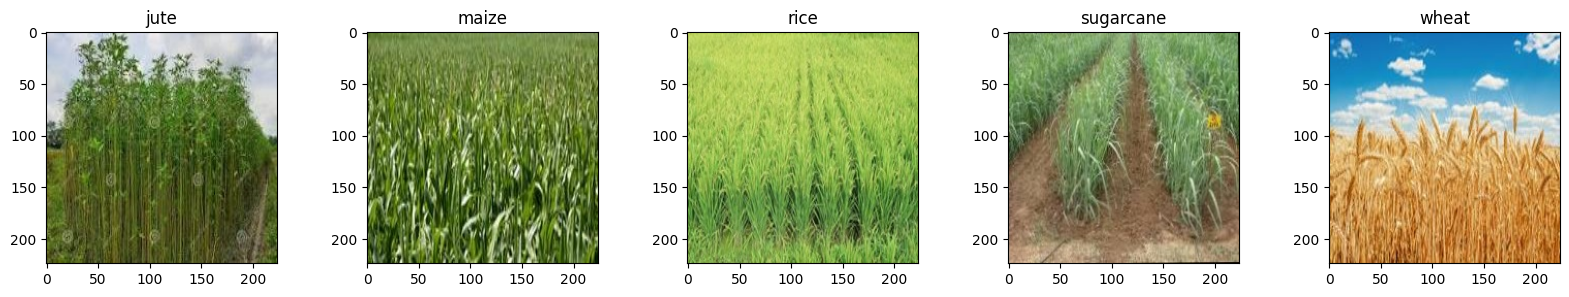

In [ ]:
wheat = plt.imread("/kaggle/input/agriculture-crop-images/kag2/wheat/wheat0004a.jpeg")
jute = plt.imread("/kaggle/input/agriculture-crop-images/kag2/jute/jute005a.jpeg")
cane = plt.imread("/kaggle/input/agriculture-crop-images/kag2/sugarcane/sugarcane0010arot.jpeg")
rice = plt.imread("/kaggle/input/agriculture-crop-images/kag2/rice/rice032ahs.jpeg")
maize = plt.imread("/kaggle/input/agriculture-crop-images/kag2/maize/maize003a.jpeg")
plt.figure(figsize=(20,3))
plt.subplot(1,5,1)
plt.imshow(jute)
plt.title("jute")
plt.subplot(1,5,2)
plt.imshow(maize)
plt.title("maize")
plt.subplot(1,5,3)
plt.imshow(rice)
plt.title("rice")
plt.subplot(1,5,4)
plt.imshow(cane)
plt.title("sugarcane")
plt.subplot(1,5,5)
plt.imshow(wheat)
plt.title("wheat")

# Converting to training and testing data

In [ ]:
jutepath = "../input/agriculture-crop-images/kag2/jute"
maizepath = "../input/agriculture-crop-images/kag2/maize"
ricepath = "../input/agriculture-crop-images/kag2/rice"
sugarcanepath = "../input/agriculture-crop-images/kag2/sugarcane"
wheatpath = "../input/agriculture-crop-images/kag2/wheat"

jutefilename = os.listdir(jutepath)
maizefilename = os.listdir(maizepath)
ricefilename = os.listdir(ricepath)
sugarcanefilename = os.listdir(sugarcanepath)
wheatfilename = os.listdir(wheatpath)

X= []

Labels

In [ ]:
for fname in jutefilename:
    X.append([os.path.join(jutepath,fname),0])
for fname in maizefilename:
    X.append([os.path.join(maizepath,fname),1])
for fname in ricefilename:
    X.append([os.path.join(ricepath,fname),2])
for fname in sugarcanefilename:
    X.append([os.path.join(sugarcanepath,fname),3])
for fname in wheatfilename:
    X.append([os.path.join(wheatpath,fname),4])
X = pd.DataFrame(X,columns = ['path','labels'])

In [ ]:
X.head()

,path,labels
0,../input/agriculture-crop-images/kag2/jute/jut...,0
1,../input/agriculture-crop-images/kag2/jute/jut...,0
2,../input/agriculture-crop-images/kag2/jute/jut...,0
3,../input/agriculture-crop-images/kag2/jute/jut...,0
4,../input/agriculture-crop-images/kag2/jute/jut...,0


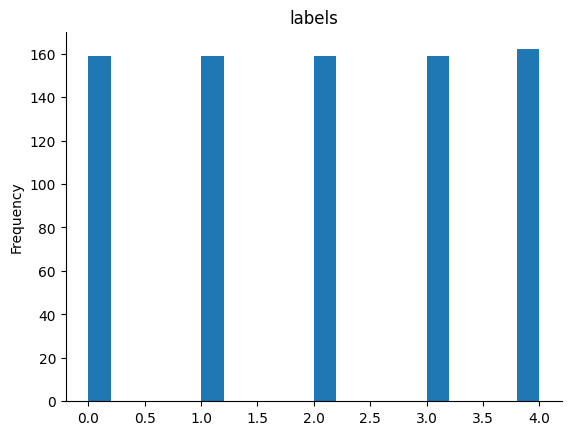

In [ ]:
# @title labels

from matplotlib import pyplot as plt
X['labels'].plot(kind='hist', bins=20, title='labels')
plt.gca().spines[['top', 'right',]].set_visible(False)

Encoding

In [ ]:

ohencoder = OneHotEncoder(handle_unknown='ignore',sparse=False)
ohlabel = pd.DataFrame(ohencoder.fit_transform(X[['labels']]),dtype = 'int64',columns = ['label0','label1','label2','label3','label4'])
label_X = X.copy()
X = pd.concat([X,ohlabel],axis = 1)
new_X = X.drop(['labels'],axis = 1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
train,test = train_test_split(label_X,test_size=0.2,random_state=0,shuffle = True)

In [ ]:
X_train = train['path'].values
y_train = train.drop(['path'],axis=1).values
X_test = test['path'].values
y_test = test.drop(['path'],axis=1).values

In [ ]:
def flat_x(data):
    flat = []
    for i in data:
        img = plt.imread(i)
        img = img/255.
        flat.append(img.reshape([1,-1]))
    flat =  np.array(flat)
    flat = flat.reshape(-1,224*224*3)
    return flat
def flat_x_oned(data):
    data = flat_x(data)
    data  = data[:,:224*224]
    return flat

In [ ]:
flat_X_train = flat_x(X_train)
flat_X_test = flat_x(X_test)

# PCA decomposition

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca=pca.fit_transform(flat_X_train)
print(flat_X_train.shape)
print(X_train_pca.shape)

(638, 150528)
(638, 2)


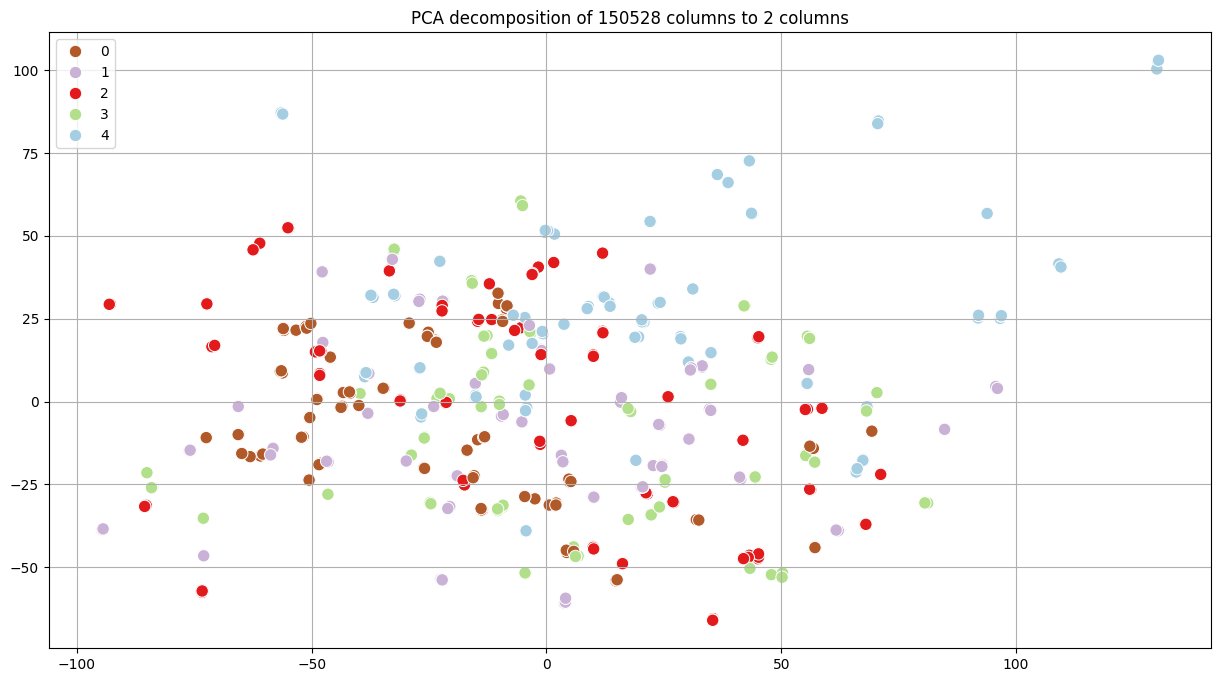

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=np.ravel(y_train), palette='Paired_r', s=80)
plt.title("PCA decomposition of 150528 columns to 2 columns")
plt.grid()
plt.show()

# TSNE decomposition

In [ ]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2,random_state=0)
X_train_tsne=tsne.fit_transform(flat_X_train[:,:224*224])
print(flat_X_train.shape)
print(X_train_pca.shape)

(638, 150528)
(638, 2)


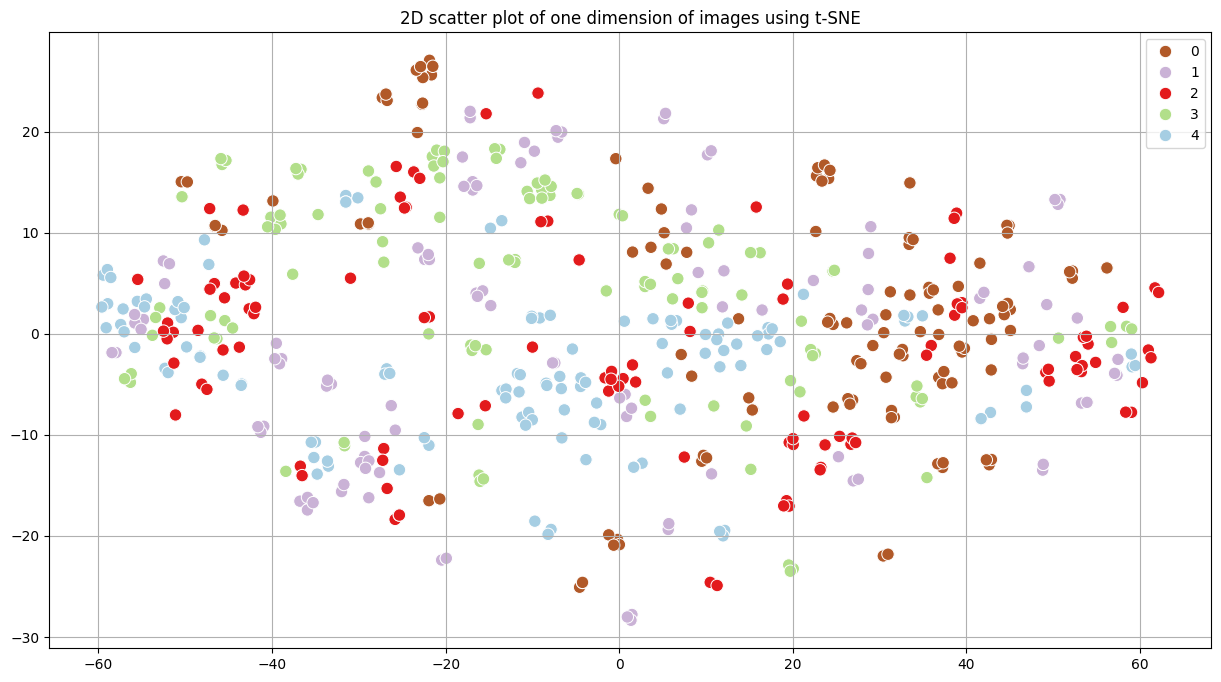

In [ ]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], hue=np.ravel(y_train), palette='Paired_r', s=80)
plt.title("2D scatter plot of one dimension of images using t-SNE")
plt.grid()
plt.show()


# Model training

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(flat_X_train,np.ravel(y_train))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier
svm = SVC()

# Fit the SVM model to the training data
svm.fit(flat_X_train, np.ravel(y_train))

SVC()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors to consider
    'weights': ['uniform', 'distance'],  # Weighting scheme for neighbors
    'metric': ['euclidean', 'manhattan']  # Distance metric
}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Perform grid search to find the best parameters
grid_search.fit(flat_X_train, np.ravel(y_train))

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

# Test Score

In [ ]:
grid_search.score(flat_X_test,np.ravel(y_test))

0.88125

In [ ]:
svm.score(flat_X_test,np.ravel(y_test))

0.8625

In [ ]:
lr.score(flat_X_test,np.ravel(y_test))

0.825

In [ ]:
from sklearn.metrics import classification_report
y_pred = svm.predict(flat_X_test)  # Assuming flat_X_test is your test data
report = classification_report(y_test, y_pred)  # Assuming y_test is your true labels for test data
print(report)

In [ ]:
from sklearn.metrics import classification_report
y_pred = lr.predict(flat_X_test)  # Assuming flat_X_test is your test data
report = classification_report(y_test, y_pred)  # Assuming y_test is your true labels for test data
print(report)

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        28
           1       1.00      0.55      0.71        33
           2       0.72      0.88      0.79        33
           3       0.86      0.97      0.91        32
           4       0.75      0.88      0.81        34

    accuracy                           0.82       160
   macro avg       0.85      0.83      0.82       160
weighted avg       0.85      0.82      0.82       160



In [ ]:
from sklearn.metrics import classification_report
y_pred = grid_search.predict(flat_X_test)  # Assuming flat_X_test is your test data
report = classification_report(y_test, y_pred)  # Assuming y_test is your true labels for test data
print(report)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        28
           1       0.93      0.76      0.83        33
           2       0.83      0.91      0.87        33
           3       0.89      1.00      0.94        32
           4       0.91      0.88      0.90        34

    accuracy                           0.88       160
   macro avg       0.88      0.88      0.88       160
weighted avg       0.88      0.88      0.88       160



In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define a function to plot ROC curve
def plot_roc_curve(model, X_test, y_test, label):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (area = {roc_auc:.2f})')

# Plot ROC curves for all three models
plt.figure(figsize=(8, 6))

# Plot ROC curve for grid search (KNN)
plot_roc_curve(grid_search, flat_X_test, y_test, 'Grid Search (KNN)')

# Plot ROC curve for logistic regression (lr)
plot_roc_curve(lr, flat_X_test, y_test, 'Logistic Regression')

# Plot ROC curve for support vector machine (svm)
plot_roc_curve(svm, flat_X_test, y_test, 'Support Vector Machine')

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Set plot labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


NameError: name 'grid_search' is not defined

<Figure size 800x600 with 0 Axes>

# Pipelining

In [ ]:
def modelpipeline(imagepath,model = lr,label=-1):
    pdict = {0:"jute",1:"maize",2:"rice",3:"sugarcane",4:"wheat"}
    pred_x = flat_x([imagepath])
    pred = model.predict(pred_x)
    plt.imshow(plt.imread(imagepath))
    if (label!=-1):
        plt.title("prediction : {} \naccurate  : {}".format(pdict[pred[0]],pdict[label]))
    else:
        plt.title("prediction : {}".format(pdict[pred[0]]))

# Prediction on sample images

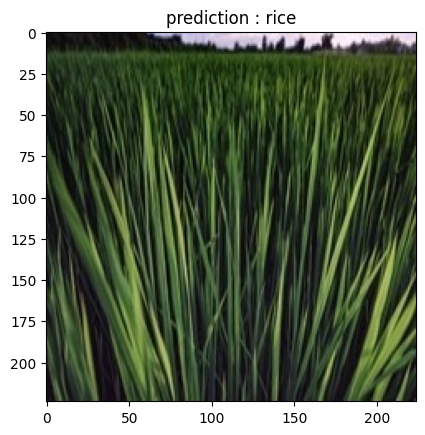

In [ ]:
modelpipeline('/kaggle/input/agriculture-crop-images/kag2/rice/rice024ahs.jpeg')

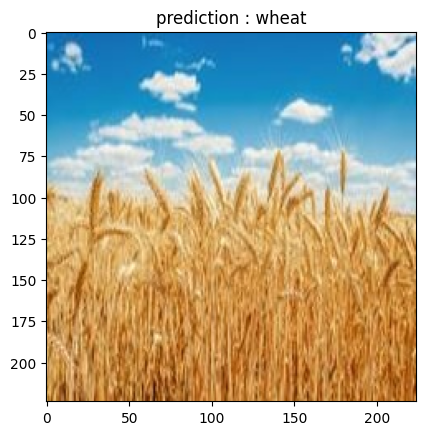

In [ ]:
modelpipeline('../input/agriculture-crop-images/kag2/wheat/wheat0004a.jpeg')

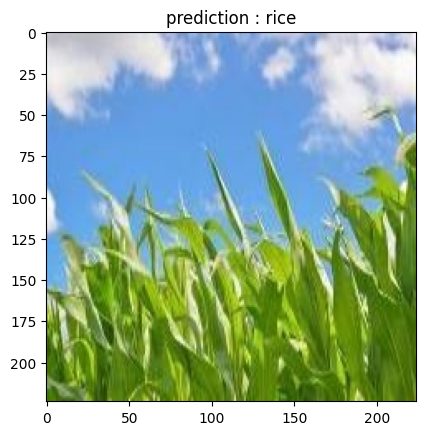

In [ ]:
modelpipeline("../input/agriculture-crop-images/kag2/maize/maize008ahf.jpeg")

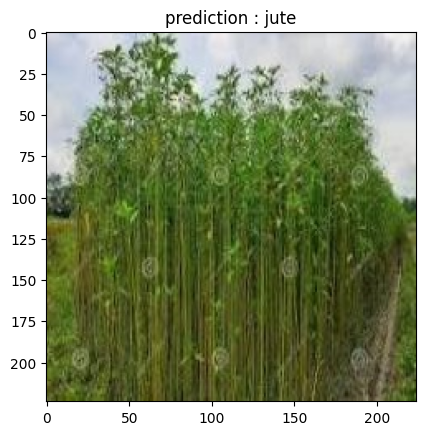

In [ ]:
modelpipeline("../input/agriculture-crop-images/kag2/jute/jute005a.jpeg")

# Prediction on test images

In [ ]:
plt.figure(figsize=(20,20))
for num,path in enumerate(X_test[0:20]):
    plt.subplot(4,5,num+1)
    modelpipeline(path,lr,y_test[num][0])

In [ ]:
plt.figure(figsize=(20,20))
for num,path in enumerate(X_test[20:40]):
    plt.subplot(4,5,num+1)
    modelpipeline(path,grid_search,y_test[num+20][0])

In [ ]:
plt.figure(figsize=(20,20))
for num,path in enumerate(X_test[40:60]):
    plt.subplot(4,5,num+1)
    modelpipeline(path,svm,y_test[num+40][0])